In [ ]:
# @title Instalar librerías
%%capture
!pip install openneuro-py
!pip install mne
!pip install mne-bids
!pip install autoreject
!pip install pybids
!pip install mne-icalabel
!pip install pyprep

In [ ]:
# @title Importar librerías
import matplotlib.pyplot as plt
import pandas as pd
import json
import openneuro as on
import mne
from autoreject import AutoReject
from mne.preprocessing import ICA
from mne_icalabel import label_components
import mne_bids
import bids
import ipywidgets
import numpy as np
import pyprep

¡Bienvenidos!

En esta introducción se dará una mirada a un flujo muy básico de preprocesamiento y procesamiento de análisis EEG.

Más que definir o recomendar estándares de oro, la idea es lograr tener una noción muy general de lo que se tiene que hacer en estas etapas.

El pre procesamiento es una etapa necesaria para el análisis de datos EEG ya que los instrumentos que utilizamos para capturar actividad cerebral no siempre captan únicamente ésta, sino que también pueden verse nutridas por artefactos.


# Obtención de datos
Los datos que se utilizaran en este tutorial serán obtenidos del repositorio <a href="https://openneuro.org/"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Open Neuro**
  </a>, el cual almacena diversos conjuntos de datos neurofisiológicos de investigaciones publicadas y compartidas en el marco de la ciencia abierta. En este caso, la información de los datos que utilizaremos es la siguiente:

> Prakash Mishra, Tapan K. Gandhi, and Saurabh R. Gandhi (2026). A multimodal dataset of EEG, eye-tracking, and physiological signals during smartphone interaction. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds007537.v2.0.1

  Así como otros repositorios, **Open Neuro** utiliza un formato para la organización de sus datos, lo que permite que cualquier persona (como nosotross) pueda utilizarlos con facilidad en el futuro. Este formato es el **BIDS**

<a href="https://www.neuroinfo.org/gsp"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Brain Genomics Superstruct Project**
  </a>

<a href="https://www.ebrains.eu/"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Ebrains**
  </a>

<a href="https://brainlife.io/about/"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Brainlife**
  </a>


Y más.

<h1>Base de datos normal Vs BIDS</h1>
<figure style="text-align:center; margin: 1.25rem 0;">
  <img src="https://bids.neuroimaging.io/assets/img/dicom-reorganization-transparent-white_1000x477.png"
       alt="Dataset EEG-BIDS"
       style="display:block; margin:0 auto; max-width:100%; width:600px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Reorganización DICOM → BIDS.</figcaption>
</figure>

<h1>¿Qué hay dentro de cada archivo?</h1>
<figure style="text-align:center; margin: 1.25rem 0;">
  <img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41597-019-0104-8/MediaObjects/41597_2019_104_Fig1_HTML.png"
       alt="Dataset EEG-BIDS"
       style="display:block; margin:0 auto; max-width:100%; width:600px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Estructura interna de un dataset BIDS.</figcaption>
</figure>




In [ ]:
# @title Crear carpeta para los datos
!mkdir data

mkdir: cannot create directory ‘data’: File exists


In [ ]:
# @title El API de open neuro para descargar la base de datos
on.download(
    dataset="ds007537",  # OpenNeuro Accession Number
    target_dir="/content/data",  # Carpeta donde se guardará el dataset
    include=["sub-02"],  # Solo incluir los participantes sub-104
)


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds007537 …
📥 Checking 20 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds007537 (downloaded 0 files and 0 B).
 
🧠 Please enjoy your brains.
 


# Descripción de la base

Luego de haber usado el API de Open Neuro, podemos usar la librería BIDS para ver la estructura de la base.

Cosas como el layout (el panorama general), la lista de sujetos, la lista de tareas (experimentales), los tipos de datos (eeg, fmri, etc).

In [ ]:
# @title Descripción de la base
layout = bids.BIDSLayout("/content/data")  # guarda la estructura de las carpetas y contenidos en la variable layout


subjects_list = (layout.get_subjects())  # de la variable layout, extraemos los nombres que por organización deberían corresponder a los sujetos.


tasks_list = layout.get_tasks()  # de la variable layout, extraemos los nombres de las tasks.


datatypes = layout.get_datatypes()  # de la variable layout, extraemos los datatypes.


files_list = (layout.get_files())  # de la variable layout, extraemos los nombres de los archivos.


print(layout)

print(f"""
Subjects in the database:
{subjects_list}

Tasks in the database:
{tasks_list}

Data types in the database:
{datatypes}

Files in the database:
{files_list}
""")

layout.get_dataset_description()

BIDS Layout: .../content/data | Subjects: 1 | Sessions: 0 | Runs: 0

Subjects in the database:
['02']

Tasks in the database:
['phoneuse']

Data types in the database:
['beh', 'eeg']

Files in the database:
{'/content/data/CHANGES': <BIDSFile filename='/content/data/CHANGES'>, '/content/data/participants.json': <BIDSJSONFile filename='/content/data/participants.json'>, '/content/data/participants.tsv': <BIDSDataFile filename='/content/data/participants.tsv'>, '/content/data/dataset_description.json': <BIDSJSONFile filename='/content/data/dataset_description.json'>, '/content/data/README': <BIDSFile filename='/content/data/README'>, '/content/data/sub-02/eeg/sub-02_task-phoneuse_channels.tsv': <BIDSDataFile filename='/content/data/sub-02/eeg/sub-02_task-phoneuse_channels.tsv'>, '/content/data/sub-02/eeg/sub-02_task-phoneuse_eeg.vmrk': <BIDSFile filename='/content/data/sub-02/eeg/sub-02_task-phoneuse_eeg.vmrk'>, '/content/data/sub-02/eeg/sub-02_task-phoneuse_eeg.json': <BIDSJSONFile file

{'Name': 'A multimodal dataset of EEG, eye-tracking, and physiological signals during smartphone interaction',
 'BIDSVersion': '1.11.1',
 'DatasetType': 'raw',
 'Authors': ['Prakash Mishra', 'Tapan K. Gandhi', 'Saurabh R. Gandhi'],
 'License': 'CC0',
 'DatasetDOI': 'doi:10.18112/openneuro.ds007537.v2.0.1',
 'HEDVersion': '8.4.0',
 'GeneratedBy': [{'Name': 'Custom code',
   'Version': '1.0.0',
   'Description': 'Conversion of raw Tobii Pro Glasses 2, EEG, PPG and GSR recordings to BIDS',
   'CodeURL': 'https://github.com/csndl-iitd/ecf-natural-smartphone-neurophysiology'}],
 'SourceDatasets': [{'URL': 'Raw device recordings (Tobii Glasses 2, BrainVision EEG, PPG/GSR) held by the authors; available on reasonable request.',
   'Version': '1.0'}]}

In [ ]:
layout.to_df()

entity,path,datatype,extension,recording,space,subject,suffix,task
0,/content/data/dataset_description.json,NaN,.json,NaN,NaN,NaN,description,NaN
1,/content/data/participants.json,NaN,.json,NaN,NaN,NaN,participants,NaN
2,/content/data/participants.tsv,NaN,.tsv,NaN,NaN,NaN,participants,NaN
3,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.json,cyclopean,NaN,02,physio,phoneuse
4,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.tsv.gz,cyclopean,NaN,02,physio,phoneuse
5,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.json,cyclopean,NaN,02,physioevents,phoneuse
6,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.tsv.gz,cyclopean,NaN,02,physioevents,phoneuse
7,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.json,imu,NaN,02,physio,phoneuse
8,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.tsv.gz,imu,NaN,02,physio,phoneuse
9,/content/data/sub-02/eeg/sub-02_space-CapTrak_...,eeg,.json,NaN,CapTrak,02,coordsystem,NaN


#MNE-BIDS

Luego pasamos a leer los datos con la integración de MNE en BIDS. Ya aquí estamos leyendo directamente el formato EEG.

In [ ]:
# @title Leer los datos de Open Neuro (Organizados en formato BIDS) con MNE
raw_eeg={}

for subject in subjects_list:

# Define BIDS path
  bids_path = mne_bids.BIDSPath(
      root="/content/data",  # lugar en donde está el archivo en la máquina virtual
      subject=subject,
      task="phoneuse",  # señalamos el task que se quiere recuperar en la base de datos. Esto es necesario porque en una base de datos BIDS puedes tener varias.
      datatype="eeg",  # señalamos el tipo de datos que se quiere recuperar. En BIDS se pueden guardar distintas señales si el estudio ha utilizado varias medidas comportamentales.

  )

  # Load raw data
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.
      bids_path,  # la variable que hemos construido antes (tiene toda la información de cómo recuperar el archivo).
      verbose=False,
      extra_params={"preload": True},  # se cargan los datos a la memoria RAM.
  )
  raw=raw.resample(256)

  raw_eeg[f"sub-{subject}"]=raw
  display(raw)

/tmp/ipykernel_8717/233601882.py:16: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['GSR', 'PPG']
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.
/tmp/ipykernel_8717/233601882.py:16: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.
/tmp/ipykernel_8717/233601882.py:16: RuntimeWarning: Unable to map the following column(s) to MNE:
app_type: G
hand (subject handedness): B
audio: Y
orientation: L
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.


<RawBrainVision | sub-02_task-phoneuse_eeg.eeg, 66 x 300170 (1172.5 s), ~151.2 MiB, data loaded>

¡Ya tenemos los datos en la memoria! Ahora podemos hacer gráficos simples como la montura de los electrodos y la señal cruda.

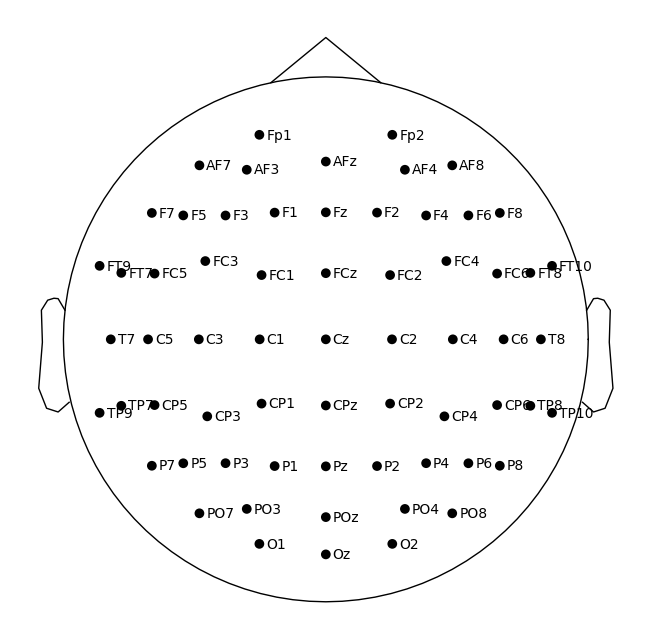

In [ ]:
plot=raw_eeg['sub-02'].plot_sensors(show_names=True)

Luego, podemos pasar al trabajo con los datos.  El flujo general que seguiremos será el siguiente:

·Imagen·

Dentro del pre procesamiento haremos los siguientes sub-pasos.

·Otra imagen·

Comenzaremos entonces con el filtrado de frecuencias.

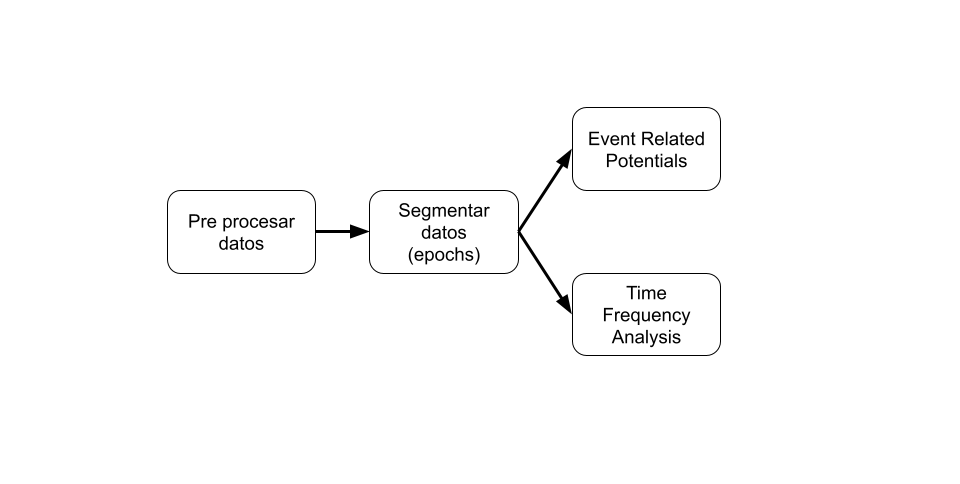

Una frecuencia se puede entender como la cantidad de veces que ocurre un evento específico dentro de un periodo de tiempo predeterminado.

Por ejemplo, 1 Hz hace referencia a que un evento ocurre una vez en un segundo, 10 Hz a diez veces en un segundo, 100 Hz a 100 veces en un segundo, etc.







In [ ]:
#@title Ｂｌａｃｋ　ｂｏｘ　（ｆｒｅｑｕｅｎｃｉｅｓ）
# Bandas EEG y sus rangos
eeg_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alfa": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 100)
}

eeg_colors = {
    "Delta": "#00ffd5",
    "Theta": "#ff00ff",
    "Alfa": "#b6ff00",
    "Beta": "#ff6ec7",
    "Gamma": "#00ffff"
}

def get_band_and_color(freq):
    for name, (low, high) in eeg_bands.items():
        if low <= freq < high:
            return name, eeg_colors[name]
    return "Fuera de rango", "#ffffff"

def plot_senoide(freq, dur):
    fs = 1000
    t = np.arange(0, dur, 1/fs)
    y = np.sin(2 * np.pi * freq * t)

    band_name, color = get_band_and_color(freq)

    fig, ax = plt.subplots(figsize=(8, 3), dpi=150)
    fig.patch.set_facecolor("#0a0f1f")
    ax.set_facecolor("#0a0f1f")

    ax.plot(t, y, linewidth=8, alpha=0.08, color=color)
    ax.plot(t, y, linewidth=2.2, color=color)

    ax.set_xlim(0, dur)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("Tiempo (s)", color="#cde3ff")
    ax.set_ylabel("Amplitud", color="#cde3ff")
    ax.set_title(
        f"Frecuencia: {freq:.2f} Hz  →  Banda: {band_name}",
        color="#e6f0ff",
        pad=10
    )

    for spine in ax.spines.values():
        spine.set_color("#20345c")
        spine.set_linewidth(1.2)

    ax.tick_params(colors="#a8c8ff")
    ax.grid(True, which="both", linewidth=0.6, alpha=0.25)
    plt.tight_layout()
    plt.show()

# Sliders
freq_slider = ipywidgets.FloatSlider(
    value=10.0, min=0.5, max=50.0, step=0.5,
    description='Frecuencia (Hz):'
)

dur_slider = ipywidgets.FloatSlider(
    value=1.6, min=0.1, max=1.0, step=0.1,
    description='Duración (s):'
)

ipywidgets.interactive(
    plot_senoide,
    freq=freq_slider,
    dur=dur_slider
)

interactive(children=(FloatSlider(value=10.0, description='Frecuencia (Hz):', max=50.0, min=0.5, step=0.5), Fl…

# ¿Qué pasa cuando captamos varios eventos en distintas frecuencias al mismo  tiempo?



<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/02.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Frecuencias de actividad cerebral.</figcaption>
</figure>

<br>

<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/01.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:80%; width:600px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Frecuencias juntas.</figcaption>
</figure>


<br>

Las frecuencias que puede captar el EEG no solamente son del cerebro, sino también de la electricidad del aparato mismo o artefactos creados por movimientos del participante. Por eso es necesario filtrarlas. En este caso, le aplicaremos un filtrado estándar en análisis de neurociencia.

El filtrado es:
- Bandpass entre 0.1-40 Hz (Esto hace que sólo se mantengan las frecuencias arriba de 0.1 y 40 Hz).

- Filtros notch (de frecuencia específica) en 50 y 60 Hz.

In [ ]:
filtered_eeg={}
for subject, raw in raw_eeg.items():
  eeg=raw.copy()
  eeg=eeg.filter(l_freq=0.1,
             h_freq=40
             )
  eeg=eeg.notch_filter(freqs=(50,60))
filtered_eeg[subject]=eeg

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8449 samples (33.004 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)



Luego del filtrado, utilizaremos un algoritmo para detectar electrodos que tienen señal dañada y, posteriormente, interpolaremos los electrodos.

#¿Qué es interpolar?


<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/da-falcon/event_hri/refs/heads/main/resources/01_ai.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Ilustración de interpolación.</figcaption>
</figure>



In [ ]:
#@title Detección y apunte de canales dañados

for subject, eeg in filtered_eeg.items():
  eeg_pyprep=eeg.copy()
  noisy=pyprep.NoisyChannels(
      raw=eeg_pyprep,
      do_detrend=False,
      random_state=7
  )
  noisy.find_all_bads()
  eeg_pyprep.info['bads']=noisy.get_bads()
  raw_eeg[subject].info['bads']=noisy.get_bads()
  results=noisy.get_bads(as_dict=True)
  print(f"Resultados de sujeto {subject}:{results}")
  filtered_eeg[subject]=eeg_pyprep

  0%|          |  : 0/234 [00:00<?,       ?it/s]

Resultados de sujeto sub-02:{'bad_by_nan': [], 'bad_by_flat': ['Cz'], 'bad_by_deviation': [], 'bad_by_hf_noise': ['FC3'], 'bad_by_correlation': ['CP1', 'FC3', 'C1', 'PO3'], 'bad_by_SNR': ['FC3'], 'bad_by_dropout': [], 'bad_by_psd': ['PO3'], 'bad_by_ransac': [np.str_('C3'), np.str_('CP5'), np.str_('CP6'), np.str_('CP2'), np.str_('C4'), np.str_('FC2'), np.str_('AFz'), np.str_('C5'), np.str_('CP3'), np.str_('P1'), np.str_('P2'), np.str_('CPz'), np.str_('CP4'), np.str_('C6'), np.str_('C2'), np.str_('FC4'), np.str_('F2')], 'bad_by_manual': [], 'bad_all': [np.str_('CP6'), 'C1', np.str_('P2'), 'CP1', np.str_('CP4'), np.str_('C3'), np.str_('C6'), 'PO3', 'Cz', np.str_('AFz'), np.str_('C2'), np.str_('FC4'), np.str_('CP2'), np.str_('CP5'), np.str_('C5'), np.str_('F2'), np.str_('CPz'), np.str_('FC2'), np.str_('C4'), 'FC3', np.str_('CP3'), np.str_('P1')]}


In [ ]:
display(filtered_eeg['sub-02'])

for subject, eeg in filtered_eeg.items():
  eeg_int=eeg.copy()
  eeg_int=eeg_int.interpolate_bads(reset_bads=True)
  filtered_eeg[subject]=eeg_int
display(filtered_eeg['sub-02'])


<RawBrainVision | sub-02_task-phoneuse_eeg.eeg, 66 x 300170 (1172.5 s), ~151.2 MiB, data loaded>

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 42 sensor positions
Interpolating 22 sensors


<RawBrainVision | sub-02_task-phoneuse_eeg.eeg, 66 x 300170 (1172.5 s), ~151.2 MiB, data loaded>

# Análisis de Componentes Independientes.

Otra de las técnicas para poder limpiar la señal es el análisis de componentes independientes (ICA). Desde esta perspectiva, se intenta descomponer la señal en fuentes independientes de actividad eléctrica particular, como parpedeos, movimientos musculares, etc.  

Podemos imaginar que, en teoría, la señal entera es el resultado de distintas fuentes independientes mezclándose. Si identificamos las que no pertenecen a actividad cerebral, podemos extraerlas y quedarnos sólo con lo "cerebral" de la señal.

<br>
<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/da-falcon/event_hri/refs/heads/main/resources/02_ai.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Señal EEG siendo creada. Imagen verídica.</figcaption>
</figure>

<br>


In [ ]:
iclabel_eeg={}
for subject, eeg in filtered_eeg.items():
  destiny_eeg=eeg.copy()
  destiny_eeg=destiny_eeg.set_eeg_reference('average', ch_type='eeg')

  train_eeg=raw_eeg[subject].copy()
  train_eeg=train_eeg.filter(l_freq=1,
                             h_freq=100)
  train_eeg=train_eeg.notch_filter(freqs=(50, 60))
  train_eeg=train_eeg.interpolate_bads(reset_bads=True)
  train_eeg=train_eeg.set_eeg_reference('average', ch_type='eeg')

  ica = mne.preprocessing.ICA(
              n_components=0.999999, #Rank o dimensiones independientes.
              method = "infomax",  # Método a elegir.
              fit_params = {'extended':True}, #Parámetros del método, hay "infomax" e "infomax extended". Queremos el extended.
              max_iter = "auto",  # Maximum number of iterations; typically should be higher, like 500 or 1000
              random_state = 7  # Lucky!
          )

  ica.fit(train_eeg, picks='eeg')

  eog_indices, eog_scores = ica.find_bads_eog( #Este es el método.
    train_eeg, #pasamos nuestro set de entrenamiento
    ch_name=['Fp1', 'Fp2'],
    threshold=3.0,
    verbose=False
    )

  ic_labels = label_components(train_eeg, ica, method="iclabel")
  labels = ic_labels["labels"]
  probs = ic_labels["y_pred_proba"]

  exclude_idx = [
      idx for idx, (label, prob) in enumerate(zip(labels, probs))
      if label not in ["brain", "other"] and prob > 0.9
  ]

  ica.exclude = exclude_idx

  ica.exclude = list(set(ica.exclude + eog_indices))

  eeg_clean = ica.apply(destiny_eeg.copy())
  iclabel_eeg[subject]=eeg_clean

Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 

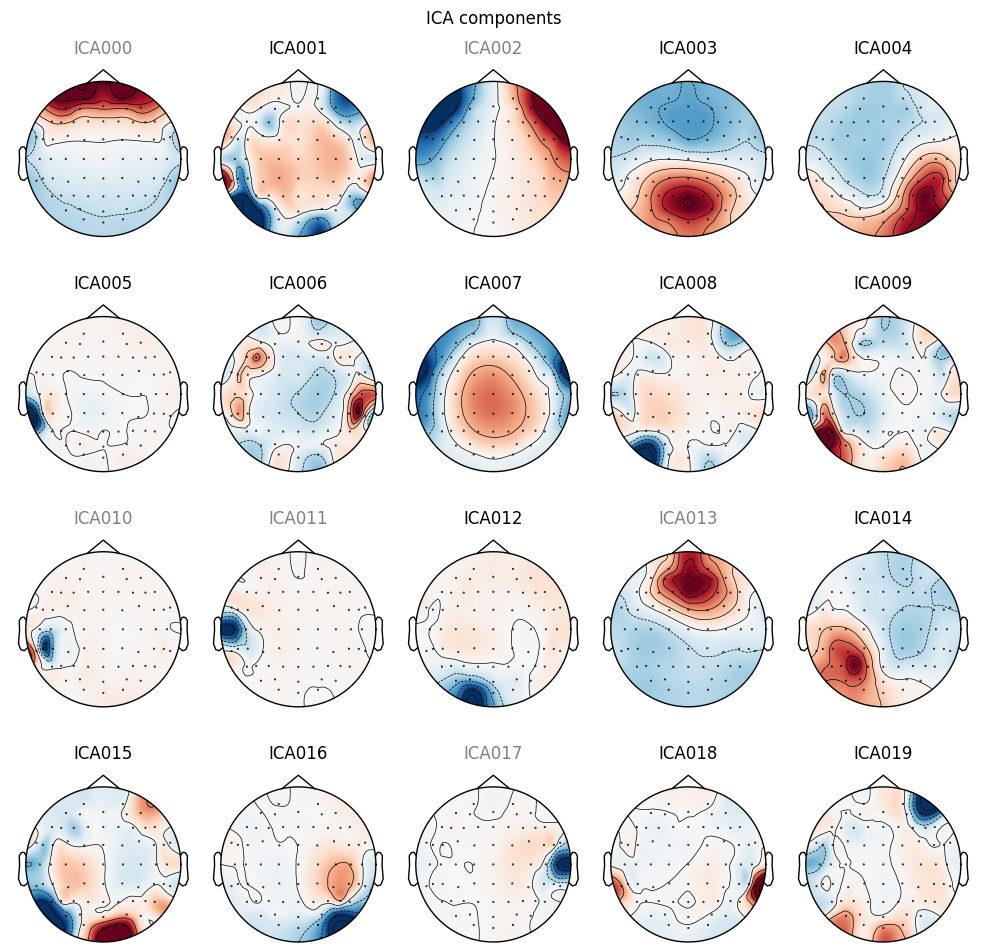

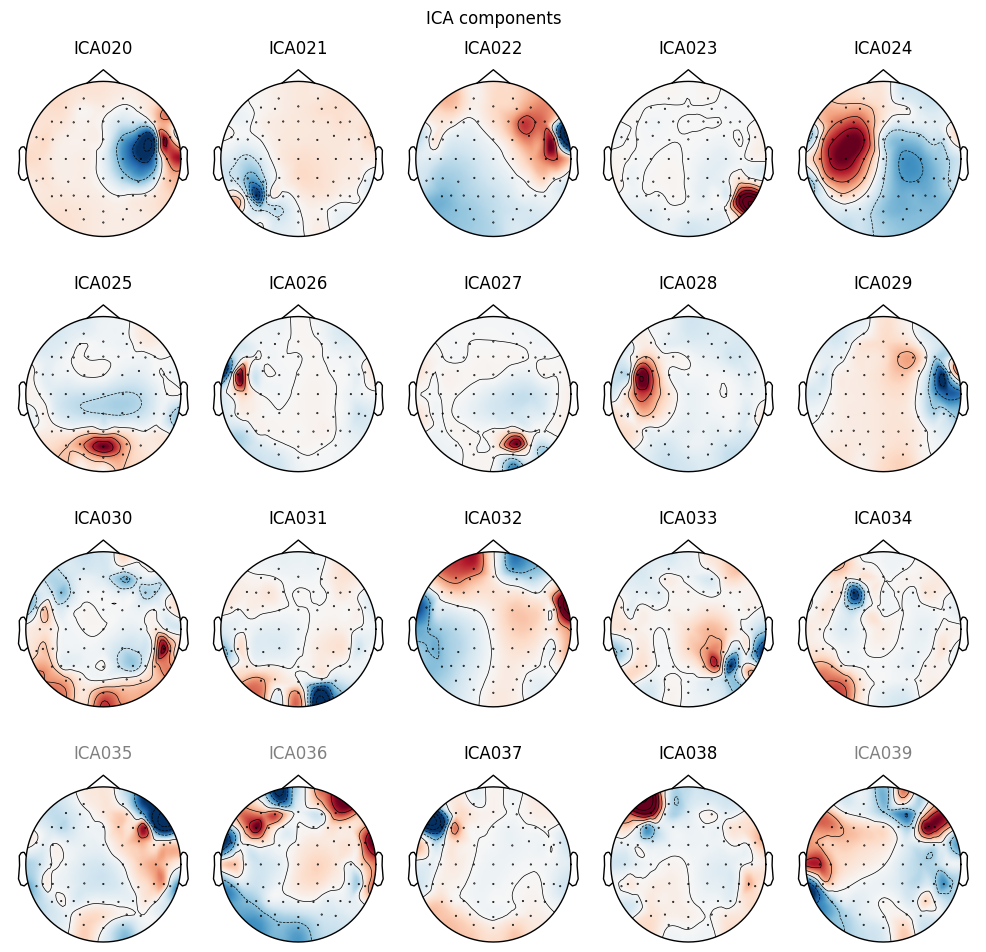

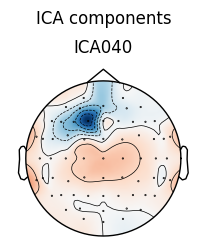

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 195x260.5 with 1 Axes>]

In [ ]:
ica.plot_components()

# Epochs: Cortar la señal.

Después de haber pre procesado la señal EEG entera, podemos pasar a la etapa clave de dividir fragmentos de la señal que nos interesan, según nuestro diseño experimental.


Si revisamos la página de la base de datos en Open Neuro para obtener más información del experimento, podemos observar que hay dos estímulos de interés, alrededor de los cuales se han codificado eventos.

---

*EEG event markers are defined for two conditions:*

*Smartphone Monitor (**onset: S 12**; **offset: S 13**)*

*Video Monitor (**onset: S 22**; **offset: S 23**).*

---


Estos eventos están guardados en el objeto que hemos estado pre procesando. Sólo hace falta recuperarlo con un par de métodos integrados.

In [ ]:
events, event_id = mne.events_from_annotations(iclabel_eeg['sub-02'])

print(events)
print(event_id)

Used Annotations descriptions: [np.str_('Comment/Active Shielding: On'), np.str_('New Segment/'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 13'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S 23')]
[[     0      0  99999]
 [     0      0  10001]
 [     0      0  99999]
 [     0      0  10001]
 [ 58581      0     11]
 [ 58581      0     11]
 [ 58838      0     11]
 [ 58838      0     11]
 [ 59094      0     11]
 [ 59094      0     11]
 [ 59350      0     11]
 [ 59350      0     11]
 [ 59606      0     11]
 [ 59606      0     11]
 [ 59862      0     12]
 [ 59862      0     12]
 [ 64977      0     12]
 [ 64977      0     12]
 [ 70096      0     12]
 [ 70096      0     12]
 [ 75215      0     12]
 [ 75215      0     12]
 [ 80335      0     12]
 [ 80335      0     12]
 [ 85454      0     12]
 [ 85454      0     12]
 [ 90573      0     12]
 [ 90573      0     12]
 [ 95693      0     12]
 [ 95693      0     12]
 [100812      0     12]
 [

Luego de haberlos recuperado, podemos utilizar la función para hacer Epochs de MNE, el cual cortará la señal tomando los eventos como referencia.

Los eventos son el tiempo 0, y usando esta referencia podemos indicar desde dónde hasta dónde queremos el corte.

In [ ]:
epochs=mne.Epochs(
    iclabel_eeg['sub-02'],
    events=events,
    tmin=-0.2,
    tmax=1,
    event_id=event_id,
    event_repeated='drop',
    reject=dict(eeg=100e-6)
)
epochs=epochs.apply_baseline((-0.2,0))

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
66 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Applying baseline correction (mode: mean)


<br>

<figure style="text-align:left; margin:0;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/05_ai.png"
       alt="montaje"
       width="400">
  <figcaption style="margin-top:.25rem; color:#555;">Ejemplo fiel de científicos haciendo epochs.</figcaption>
</figure>




<br>

Se ha obtenido entonces un corte por cada marcador de evento. En un contexto experimental, una variable de interés suele tener bastantes repeticiones (que se traducen en eventos) para poder cerciorarnos de medirla correctamente.

Esto lleva a que, en nuestro caso, tengamos varios eventos por todas las veces que el participante empezó y terminó a ver la pantalla de video o el smartphone.

Para darnos una idea de lo que ocurre, de forma general, cuando el participante ve la pantalla de video, lo que se hará es promediar todas las veces que empezó a verla. Lo mismo con el smartphone.

Esto nos permite tener, en la jerga del eeg, potenciales "evocados" por el evento.

<figure style="text-align:left; margin:0;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/07_ai.png"
       alt="montaje"
       width="400">
  <figcaption style="margin-top:.25rem; color:#555;">Científicos cognitivos creando objetos Evoked. Material real.</figcaption>
</figure>


#Potenciales relacionados a eventos

    Rejecting  epoch based on EEG : ['TP9', 'C4', 'PO8']
    Rejecting  epoch based on EEG : ['TP9', 'P7', 'O2', 'TP10', 'FT7', 'PO7']
    Rejecting  epoch based on EEG : ['F3', 'FC5', 'T7', 'TP9', 'CP1', 'Oz', 'O2', 'TP10', 'CP2', 'C4', 'FC2', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'FT7', 'C5', 'TP7', 'P1', 'P5', 'PO7', 'PO4', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'Cz']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['F3', 'C3', 'T7', 'TP9', 'CP1', 'P7', 'O2', 'P8', 'CP2', 'C4', 'FC2', 'F8', 'C1', 'TP7', 'CP3', 'P1', 'PO7', 'CP4', 'C2', 'AF8']
    Rejecting  epoch based on EEG : ['TP9', 'P7', 'Oz', 'O2', 'PO7', 'AF8']
    Rejecting  epoch based on EEG : ['TP9', 'P7', 'O2', 'TP10', 'F8', 'PO7', 'AF8']


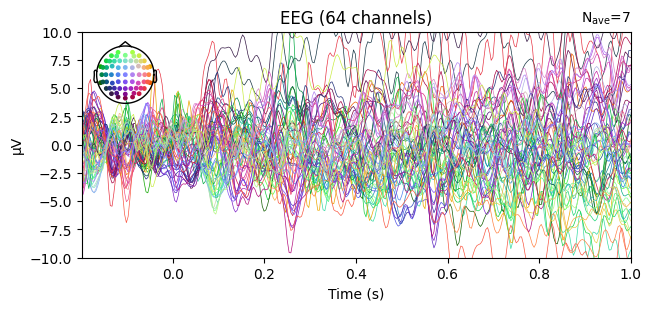

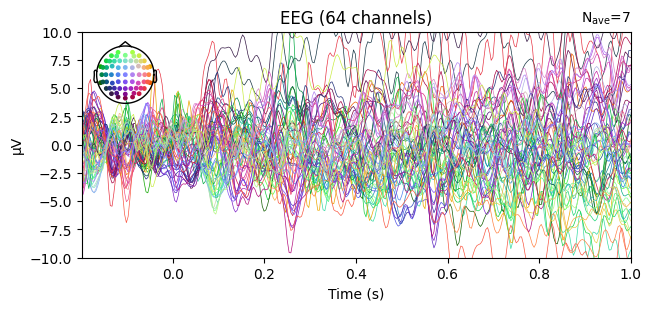

In [ ]:
evoked_video_monitor=epochs['Stimulus/S 22'].average() # Pantalla de video
evoked_video_monitor.plot(ylim=dict(eeg=[-10, 10]))

Es difícil poder ver qué ocurre cuando se tienen todos los electrodos en un gráfico, pero felizmente se pueden indicar qué electrodos específicos visualizar.

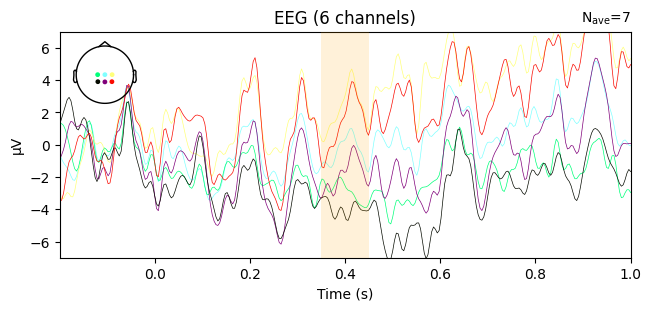

In [ ]:
roi=['Cz','C1','C2','CPz', 'CP1', 'CP2']
plot1=evoked_video_monitor.plot(picks=roi,highlight=[0.350, 0.450], ylim=dict(eeg=[-7, 7]))

Sólo de manera ilustrativa, se hará lo mismo con la condición del smartphone, para ver cómo difiere la actividad eléctrica entre condiciones.

    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['TP10']
    Rejecting  epoch based on EEG : ['F3', 'O1', 'FT7', 'PO7', 'PO8', 'TP8', 'AF8']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['P7', 'O2', 'F5', 'TP7', 'PO7', 'AF8']
    Rejecting  epoch based on EEG : ['O2', 'PO7']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['F3', 'F7', 'T7', 'CP1', 'CP2', 'C4', 'T8', 'FC2', 'F5', 'FT7', 'C1', 'TP7', 'CP3', 'P1', 'CPz', 'TP8', 'C2', 'AF8', 'Cz']


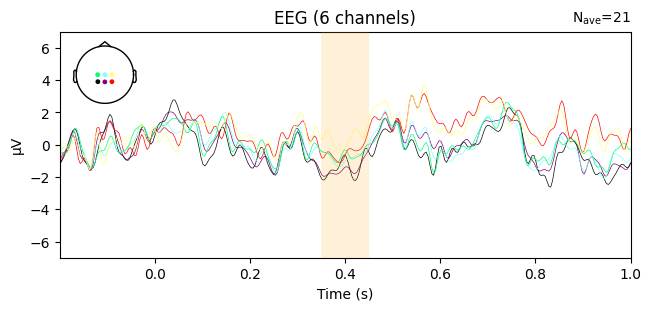

In [ ]:
roi=['CPz','CP1','CP2','Cz','C1','C2']
evoked_smart_monitor=epochs['Stimulus/S 12'].average() #pantalla de smartphone
plot2=evoked_smart_monitor.plot(picks=roi,highlight=[0.350, 0.450], ylim=dict(eeg=[-7, 7]))

¿Habrá algún indicio de potencial visual?

    Rejecting  epoch based on EEG : ['TP9', 'C4', 'PO8']
    Rejecting  epoch based on EEG : ['TP9', 'P7', 'O2', 'TP10', 'FT7', 'PO7']
    Rejecting  epoch based on EEG : ['F3', 'FC5', 'T7', 'TP9', 'CP1', 'Oz', 'O2', 'TP10', 'CP2', 'C4', 'FC2', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'FT7', 'C5', 'TP7', 'P1', 'P5', 'PO7', 'PO4', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'Cz']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['F3', 'C3', 'T7', 'TP9', 'CP1', 'P7', 'O2', 'P8', 'CP2', 'C4', 'FC2', 'F8', 'C1', 'TP7', 'CP3', 'P1', 'PO7', 'CP4', 'C2', 'AF8']
    Rejecting  epoch based on EEG : ['TP9', 'P7', 'Oz', 'O2', 'PO7', 'AF8']
    Rejecting  epoch based on EEG : ['TP9', 'P7', 'O2', 'TP10', 'F8', 'PO7', 'AF8']


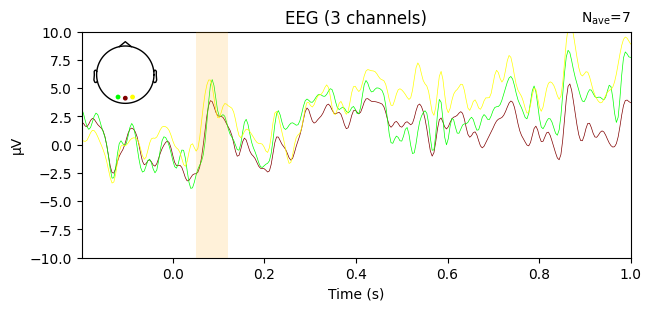

In [ ]:
roi=['Oz','O1','O2']
evoked_visual_vmonitor=epochs['Stimulus/S 22'].average()
plot_v1=evoked_visual_vmonitor.plot(picks=roi,highlight=[0.05, 0.12], ylim=dict(eeg=[-10, 10]))

    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['TP10']
    Rejecting  epoch based on EEG : ['F3', 'O1', 'FT7', 'PO7', 'PO8', 'TP8', 'AF8']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['P7', 'O2', 'F5', 'TP7', 'PO7', 'AF8']
    Rejecting  epoch based on EEG : ['O2', 'PO7']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['F3', 'F7', 'T7', 'CP1', 'CP2', 'C4', 'T8', 'FC2', 'F5', 'FT7', 'C1', 'TP7', 'CP3', 'P1', 'CPz', 'TP8', 'C2', 'AF8', 'Cz']


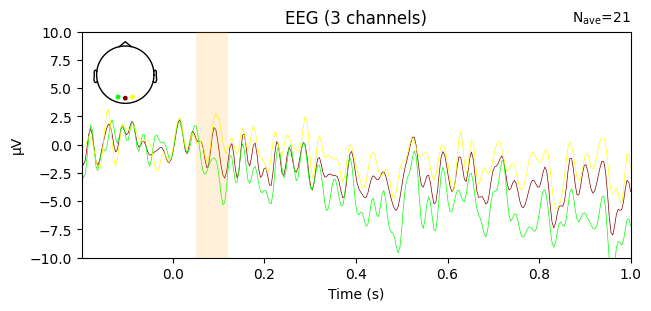

In [ ]:
roi=['Oz', 'O1', 'O2']
evoked_visual_smonitor=epochs['Stimulus/S 12'].average()
plot_v2=evoked_visual_smonitor.plot(picks=roi,highlight=[0.05, 0.12], ylim=dict(eeg=[-10, 10]))

#Explorando

¿Qué otros métodos pueden tener los objetos que hemos creado (<a href="https://mne.tools/stable/generated/mne.Evoked.html"
  target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">evokeds</a>)?

# Análisis de frecuencias

El otro tipo de análisis que se mencionó fue el de frecuencias. Para esto, podemos utilizar la magnitud de "poder espectral". En resumen, podría entenderse de forma muy general como cuánta fuerza tiene una frecuencia específica en un tiempo elegido.

En este caso, con los epochs ya realizados, calcularemos el poder espectral en cada electrodo a partir de cada epoch individual.

In [ ]:
#@title Black Box II — (frecuencia × amplitud)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets

eeg_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alfa":  (8, 13),
    "Beta":  (13, 30),
    "Gamma": (30, 100),
}

eeg_colors = {
    "Delta": "#00ffd5", "Theta": "#ff00ff", "Alfa": "#b6ff00",
    "Beta":  "#ff6ec7", "Gamma": "#00ffff",
}

ESCALA_MAX = 220  # µV — fixed scale


def get_band(freq):
    for name, (low, high) in eeg_bands.items():
        if low <= freq < high:
            return name
    return None


def plot_senoide(freq, amp, dur, autoescala):
    fs = 1000
    t = np.arange(0, dur, 1/fs)
    y = amp * np.sin(2 * np.pi * freq * t)

    band = get_band(freq)
    color = eeg_colors.get(band, "#ffffff")

    fig, ax = plt.subplots(figsize=(9, 3.4), dpi=150)
    fig.patch.set_facecolor("#0a0f1f")
    ax.set_facecolor("#0a0f1f")

    # space before 0
    margen = dur * 0.05
    ax.set_xlim(-margen, dur)

    # content
    ax.axhspan(0, amp, color=color, alpha=0.09)
    ax.axhline(amp, ls="--", lw=1.2, color=color, alpha=0.75)
    ax.axhline(-amp, ls=":",  lw=1.0, color=color, alpha=0.30)
    ax.axhline(0, color="#e6f0ff", lw=1.6, alpha=0.85)

    ax.plot(t, y, linewidth=8, alpha=0.08, color=color)
    ax.plot(t, y, linewidth=2.2, color=color)

    # arrow
    x0 = -margen * 0.55
    ax.annotate("", xy=(x0, amp), xytext=(x0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#e6f0ff", lw=1.8,
                                mutation_scale=14))
    ax.plot([x0], [0], marker="o", ms=4, color="#e6f0ff")

    ax.text(0.985, 0.95, f"Amplitud = {amp:.1f} µV  ({2*amp:.1f} µV peak-to-peak)",
            transform=ax.transAxes, color="#e6f0ff", fontsize=8.5,
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#0a0f1f",
                      edgecolor="#20345c", linewidth=1.0))

    if autoescala:
        ax.set_ylim(-amp * 1.35, amp * 1.35)
    else:
        ax.set_ylim(-ESCALA_MAX, ESCALA_MAX)

    ax.set_xlabel("Tiempo (s)", color="#cde3ff")
    ax.set_ylabel("Amplitud (µV)", color="#cde3ff")

    sub = band if band else "Fuera de rango EEG"
    ax.set_title(f"{freq:.2f} Hz →  {sub}  ·  {amp:.1f} µV",
                 color="#e6f0ff", pad=10)

    for spine in ax.spines.values():
        spine.set_color("#20345c"); spine.set_linewidth(1.2)
    ax.tick_params(colors="#a8c8ff")
    ax.grid(True, linewidth=0.6, alpha=0.20)
    plt.tight_layout()
    plt.show()


ipywidgets.interactive(
    plot_senoide,
    freq=ipywidgets.FloatSlider(value=10.0, min=0.5, max=50.0, step=0.5,
                                description='Frecuencia (Hz):',
                                style={'description_width': 'initial'},
                                continuous_update=False),
    amp=ipywidgets.FloatSlider(value=30.0, min=0.5, max=200.0, step=0.5,
                               description='Amplitud (µV):',
                               style={'description_width': 'initial'},
                               continuous_update=False),
    dur=ipywidgets.FloatSlider(value=1.6, min=0.1, max=2.0, step=0.1,
                               description='Duración (s):',
                               style={'description_width': 'initial'},
                               continuous_update=False),
    autoescala=ipywidgets.Checkbox(value=False, description='Autoescala Y'),
)

interactive(children=(FloatSlider(value=10.0, continuous_update=False, description='Frecuencia (Hz):', max=50.…

Using data from preloaded Raw for 30 events and 308 original time points ...
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['TP10']
    Rejecting  epoch based on EEG : ['F3', 'O1', 'FT7', 'PO7', 'PO8', 'TP8', 'AF8']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['P7', 'O2', 'F5', 'TP7', 'PO7', 'AF8']
    Rejecting  epoch based on EEG : ['O2', 'PO7']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['F3', 'F7', 'T7', 'CP1', 'CP2', 'C4', 'T8', 'FC2', 'F5', 'FT7', 'C1', 'TP7', 'CP3', 'P1', 'CPz', 'TP8', 'C2', 'AF8', 'Cz']
9 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


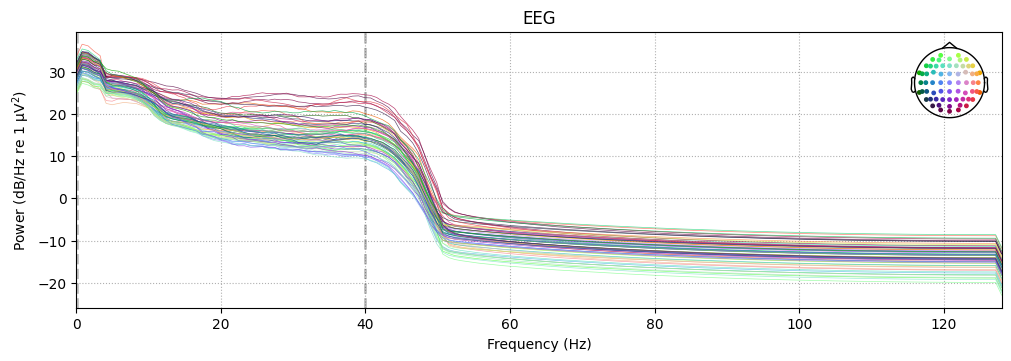

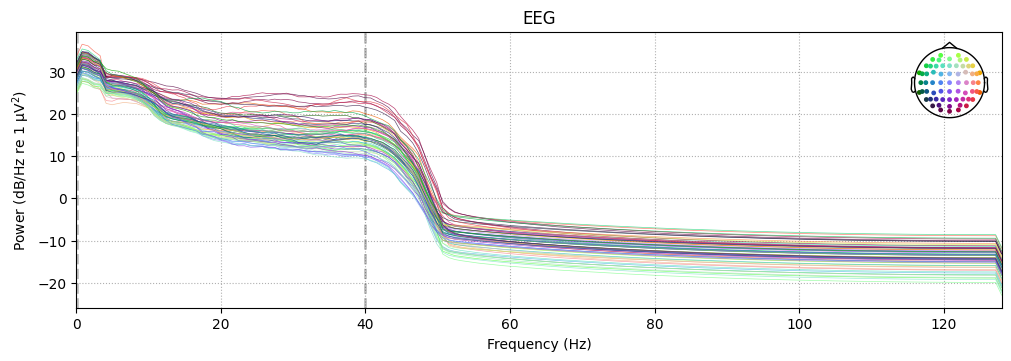

In [ ]:
power_video=epochs['Stimulus/S 12'].compute_psd()
power_video.plot()

Al calcular el poder espectral, hemos creado un nuevo objeto en donde se encuentra toda esa información {nombre del objeto]. Este es un objeto spectrum, el cual, como buen objeto de Python, tiene distintos métodos. Uno de ellos es `plot_topomap`, el cual nos servirá para obtener una visualización más espacial.



Averaging across epochs before plotting...


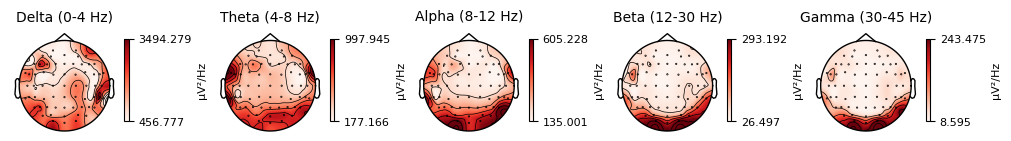

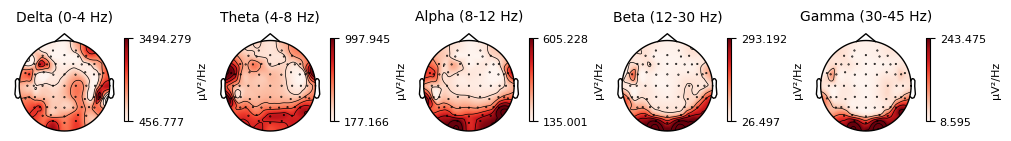

In [ ]:
power_video.plot_topomap()

¿Qué otros métodos del objeto <a href="https://mne.tools/stable/generated/mne.time_frequency.Spectrum.html"
  target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">spectrum</a> (que hemos creado para el poder espectral) pueden encontrar?

# Obteniendo los datos

Algunos se habrán dado cuenta de que la información gráfica que hemos obtenido, tanto de los potenciales relacionados a eventos como el análisis de frecuencias, proviene de objetos de Python. Estos objetos, (**evoked para amplitud**, **spectrum para las frecuencias**), también contienen la información numérica para realizar cálculos de contraste de hipótesis y demases.

Basta con usar el método {]

In [ ]:
power_video.to_data_frame()

,condition,epoch,freq,Fp1,Fz,F3,F7,FT9,FC5,FC1,...,C6,C2,FC4,FT8,F6,AF8,AF4,F2,FCz,Cz
0,Stimulus/S 12,14,0.000000,4.142889e-11,1.992233e-10,1.835291e-10,3.689442e-10,2.008167e-10,1.128613e-10,3.488075e-10,...,4.620245e-10,7.761193e-11,8.263662e-11,2.220109e-11,1.948855e-10,1.053111e-09,1.121202e-10,1.686568e-10,2.777361e-10,2.388677e-10
1,Stimulus/S 12,14,0.831169,8.510502e-11,3.219177e-10,3.487003e-10,6.067939e-10,3.075075e-10,2.079206e-10,5.980318e-10,...,9.831090e-10,1.564218e-10,1.423125e-10,8.054814e-11,3.834357e-10,2.069843e-09,2.202424e-10,2.730714e-10,4.480768e-10,4.465860e-10
2,Stimulus/S 12,14,1.662338,6.149136e-11,3.007396e-10,3.842591e-10,6.333567e-10,3.634582e-10,2.180415e-10,4.817209e-10,...,8.845950e-10,1.914127e-10,1.523994e-10,1.257022e-10,3.858430e-10,2.073305e-09,2.004452e-10,2.652239e-10,4.471188e-10,4.016187e-10
3,Stimulus/S 12,14,2.493506,7.541193e-11,2.477196e-10,2.503355e-10,5.806524e-10,4.090172e-10,1.979127e-10,4.060063e-10,...,6.918650e-10,1.765513e-10,1.254708e-10,1.357169e-10,3.224741e-10,1.465127e-09,1.910723e-10,2.212793e-10,3.765776e-10,3.538901e-10
4,Stimulus/S 12,14,3.324675,8.880847e-11,2.584706e-10,2.748688e-10,5.110439e-10,4.000581e-10,1.538159e-10,4.184642e-10,...,5.016955e-10,1.820664e-10,1.321042e-10,1.494452e-10,2.527910e-10,1.067332e-09,1.580123e-10,2.320500e-10,3.893697e-10,3.520593e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3250,Stimulus/S 12,72,124.675325,3.114718e-14,3.277257e-14,7.622840e-15,4.539654e-14,3.620370e-14,1.064776e-15,2.425867e-14,...,2.241772e-14,4.318162e-14,6.392609e-14,1.577674e-14,1.209995e-14,8.033012e-15,1.174498e-14,4.490293e-14,2.559835e-14,3.892175e-14
3251,Stimulus/S 12,72,125.506494,3.112193e-14,3.277791e-14,7.617961e-15,4.534496e-14,3.615946e-14,1.057310e-15,2.425698e-14,...,2.238441e-14,4.315835e-14,6.387209e-14,1.581673e-14,1.212737e-14,7.979258e-15,1.177203e-14,4.489864e-14,2.561933e-14,3.893996e-14
3252,Stimulus/S 12,72,126.337662,3.104812e-14,3.273707e-14,7.619756e-15,4.528086e-14,3.609491e-14,1.051038e-15,2.422019e-14,...,2.239348e-14,4.311060e-14,6.383332e-14,1.576951e-14,1.211189e-14,7.991543e-15,1.175053e-14,4.486110e-14,2.559456e-14,3.888544e-14
3253,Stimulus/S 12,72,127.168831,3.105183e-14,3.273301e-14,7.612729e-15,4.526913e-14,3.610657e-14,1.052462e-15,2.421881e-14,...,2.236014e-14,4.308932e-14,6.379884e-14,1.574653e-14,1.210134e-14,7.987577e-15,1.174895e-14,4.485087e-14,2.559266e-14,3.887266e-14


In [ ]:
evoked_video_monitor.to_data_frame()

,time,Fp1,Fz,F3,F7,FT9,FC5,FC1,C3,T7,...,C6,C2,FC4,FT8,F6,AF8,AF4,F2,FCz,Cz
0,-0.199219,0.508220,0.402041,2.225010,0.608426,-0.914189,1.512607,1.336046,2.337577,1.713783,...,-3.415271,-3.014601,-2.218903,-1.848679,-0.889540,0.080107,-0.293060,-0.081277,0.617010,-0.612466
1,-0.195312,0.280777,-0.286350,2.146247,0.422918,-0.627978,1.393553,0.925064,2.535636,1.912217,...,-2.578961,-3.350084,-2.430904,-1.485687,-0.708672,0.737100,-0.446560,-0.857576,-0.222891,-0.888619
2,-0.191406,-0.203944,-1.063445,1.368395,0.749809,-0.085285,0.714868,0.235747,2.398095,1.701493,...,-1.392031,-3.348158,-2.322768,-1.179582,-0.610078,0.901010,-0.735790,-1.570477,-1.144379,-1.118473
3,-0.187500,-0.970615,-1.906536,-0.099822,1.059744,0.238359,-0.322872,-0.701268,1.855878,0.981126,...,-0.079529,-3.124138,-2.135304,-0.520761,-0.805175,0.275160,-1.343623,-2.263856,-2.069459,-1.286045
4,-0.183594,-1.780890,-2.723817,-1.621707,0.937196,0.178874,-1.248388,-1.682889,1.087805,0.147862,...,0.951468,-2.959942,-2.101210,0.555341,-1.169499,-0.792775,-2.083755,-2.928704,-2.925702,-1.443120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,0.984375,-3.893389,-1.855877,-11.134259,-6.560969,0.054954,-4.504679,-2.582540,-3.770058,-1.460651,...,0.244166,6.044203,2.638380,-5.320752,-5.184114,-2.884690,-6.730000,-1.297279,-2.956985,0.237181
304,0.988281,-3.774544,-1.596376,-10.772535,-7.349546,-0.012052,-4.535163,-2.466304,-3.452697,-1.666042,...,-0.382681,5.815907,2.683709,-5.478519,-5.292533,-3.029176,-6.643700,-1.026765,-2.669542,0.298270
305,0.992188,-3.817057,-1.628115,-10.217907,-7.636139,-0.242337,-4.425015,-2.418316,-3.004516,-1.433909,...,-0.711130,5.410750,2.440159,-5.448116,-5.779029,-3.654158,-6.864855,-1.207833,-2.631986,0.164583
306,0.996094,-4.101809,-1.911926,-9.712559,-7.500832,-0.665743,-4.406140,-2.500945,-2.799088,-1.060535,...,-0.429230,5.190721,2.123471,-5.295346,-6.425289,-4.386332,-7.347349,-1.739004,-2.767350,-0.019640


**Referencias:**


> - Gorgolewski, K. J., Auer, T., Calhoun, V. D., Craddock, R. C., Das, S., Duff, E. P., ... & Poldrack, R. A. (2016). The brain imaging data structure, a format for organizing and describing outputs of neuroimaging experiments. Scientific data, 3(1), 1-9.

> - Gramfort, A., Luessi, M., Larson, E., Engemann, D. A., Strohmeier, D., Brodbeck, C., ... & Hämäläinen, M. (2013). MEG and EEG data analysis with MNE-Python. Frontiers in Neuroinformatics, 7, 267.
[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17345411.svg)](https://doi.org/10.5281/zenodo.17345411).

>- Prakash Mishra, Tapan K. Gandhi, and Saurabh R. Gandhi (2026). A multimodal dataset of EEG, eye-tracking, and physiological signals during smartphone interaction. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds007537.v2.0.1

> - Jas, M., Engemann, D. A., Bekhti, Y., Raimondo, F., & Gramfort, A. (2017). Autoreject: Automated artifact rejection for MEG and EEG data. NeuroImage, 159, 417-429.

> - Jas, M., Engemann, D., Raimondo, F., Bekhti, Y., & Gramfort, A. (2016, June). Automated rejection and repair of bad trials in MEG/EEG. In 2016 international workshop on pattern recognition in neuroimaging (PRNI) (pp. 1-4). IEEE.

> - Appelhoff, S., Hurst, A. J., Lawrence, A., Li, A., Mantilla Ramos, Y. J., O'Reilly, C., ... & Dancker, J. (2022). PyPREP: A Python implementation of the preprocessing pipeline (PREP) for EEG data. Zenodo, 2. [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.16039994.svg)](https://doi.org/10.5281/zenodo.16039994)

> - Bigdely-Shamlo, N., Mullen, T., Kothe, C., Su, K.-M., & Robbins, K. A. (2015). The PREP pipeline: standardized preprocessing for large-scale EEG analysis. Frontiers in Neuroinformatics, 9, 16. doi: 10.3389/fninf.2015.00016

> - Mendoza-Halliday, D., Major, A. J., Lee, N., Lichtenfeld, M. J., Carlson, B., Mitchell, B., ... & Bastos, A. M. (2024). A ubiquitous spectrolaminar motif of local field potential power across the primate cortex. Nature Neuroscience, 27(3), 547-560.

> - Appelhoff, S., Sanderson, M., Brooks, T., Vliet, M., Quentin, R., Holdgraf, C., Chaumon, M., Mikulan, E., Tavabi, K., Höchenberger, R., Welke, D., Brunner, C., Rockhill, A., Larson, E., Gramfort, A., & Jas, M. (2019). MNE-BIDS: Organizing electrophysiological data into the BIDS format and facilitating their analysis. Journal of Open Source Software, 4:1896. DOI: 10.21105/joss.01896

> - Pernet, C. R., Appelhoff, S., Gorgolewski, K. J., Flandin, G., Phillips, C., Delorme, A., & Oostenveld, R. (2019). EEG-BIDS, an extension to the brain imaging data structure for electroencephalography. Scientific data, 6(1), 103.

> - Newman, A. J. Neural data science in python (2020). URL https://neuraldatascience.io/intro.html.

> - Li, A., Feitelberg, J., Saini, A. P., Höchenberger, R., & Scheltienne, M. (2022). MNE-ICALabel: Automatically annotating ICA components with ICLabel in Python. Journal of Open Source Software, 7(76), 4484.

> - Pion-Tonachini, L., Kreutz-Delgado, K., & Makeig, S. (2019). ICLabel: An automated electroencephalographic independent component classifier, dataset, and website. NeuroImage, 198, 181-197.

> - Winkler, I., Debener, S., Müller, K. R., & Tangermann, M. (2015, August). On the influence of high-pass filtering on ICA-based artifact reduction in EEG-ERP. In 2015 37th annual international conference of the IEEE engineering in medicine and biology society (EMBC) (pp. 4101-4105). IEEE.

Elaborado utilizando otros recursos elaborados por [neuropucp](https://github.com/neuropucp)